In [1]:
import brian2
from brian2 import mV, ms
import matplotlib.pyplot as plt

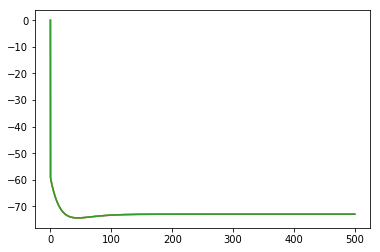

In [20]:
brian2.start_scope()
eqs_neuron_model = """
dv/dt = (-g_m*(v-v_rest) + I_syn)/C_m : volt
I_syn = I_AMPA_ext + I_NMDA_rec + I_GABA_rec : ampere
I_AMPA_ext = g_AMPA_ext*(v-V_E) : ampere
I_NMDA_rec = g_NMDA_rec*(v-V_E)/(1.0+exp(-0.062*v)/3.57)) : ampere
I_GABA_rec = g_GABA_rec*(v-V_I) : ampere
g_AMPA_ext : siemens
g_NMDA_rec : siemens
g_GABA_rec : siemens
g_m = 25*nS : siemens
C_m = 0.5*nF : farad
v_rest = -70*mV : volt
V_E = 0*mV : volt
V_I = -70*mV : volt
"""

group_PCs = brian2.NeuronGroup(3, eqs_PCs, threshold='v>-52*mV', reset='v=-59*mV')
group_RSIs = brian2.NeuronGroup(3,)

eqs_AMPA_ext = """
g_AMPA_ext_post = scl*(g_r + g_d)/norm : siemens (summed)
dg_r/dt = -g_r/tau_r : siemens
dg_d/dt = -g_d/tau_d : siemens
scl = 1 : 1
norm = 0.472689 : 1
w = 1*nS : siemens
tau_r = 0.5*ms : second
tau_d = 20*ms : second
"""
eqs_AMPA_ext_onpre = """
g_r += w
g_d += w
"""
C_AMPA_ext = brian2.Synapses(
    G, G, model=eqs_AMPA_ext, on_pre=eqs_AMPA_ext_onpre
)
C_AMPA_ext.connect('i!=j')
M = brian2.StateMonitor(G, 'v', record=list(range(G._N)))
brian2.run(500*ms)
for i in range(G._N):
    plt.plot(M.t/ms, M.v[i]/brian2.mV)